# CommonLII HTML layout EDA

This notebook scans every HTML judgment in `data/commonlii/raw/LKSC`, generates reproducible HTML-layout fingerprints, and explores how the layouts change over time. The four normalized scores are **heuristic relative scores, not calibrated model probabilities**. PDFs are reported but excluded because HTML tag fingerprints do not apply to them.

## 1. Imports and configuration

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")


def find_repo_root():
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (
            (candidate / "pyproject.toml").exists()
            and (candidate / "data/commonlii/raw/LKSC").exists()
        ):
            return candidate
    raise FileNotFoundError(
        "Could not locate the repository root containing pyproject.toml "
        "and data/commonlii/raw/LKSC."
    )


REPO_ROOT = find_repo_root()
HTML_ROOT = REPO_ROOT / "data/commonlii/raw/LKSC"
JSON_PATH = REPO_ROOT / "data/commonlii/layout-categories.json"
GENERATOR_PATH = REPO_ROOT / "scripts/1901-crawler/build_layout_categories.py"

LAYOUTS = [
    "paragraph_nlr",
    "dense_br_nlr",
    "structured_slr",
    "late_slr_font",
]

COLORS = {
    "paragraph_nlr": "#2563EB",
    "dense_br_nlr": "#F59E0B",
    "structured_slr": "#10B981",
    "late_slr_font": "#DC2626",
}

if not GENERATOR_PATH.exists():
    raise FileNotFoundError(f"Fingerprint generator not found: {GENERATOR_PATH}")

print(f"HTML archive: {HTML_ROOT}")
print(f"Fingerprint report: {JSON_PATH}")

: 

## 2. Scan the complete HTML archive and load the generated report

This cell rebuilds `layout-categories.json` from every `*/*.html` file on each run. Existing empty or stale JSON is replaced atomically.

In [ ]:
completed = subprocess.run(
    [
        sys.executable,
        str(GENERATOR_PATH),
        "--input",
        str(HTML_ROOT),
        "--output",
        str(JSON_PATH),
    ],
    check=True,
    capture_output=True,
    text=True,
)
print(completed.stdout.strip())

report = json.loads(JSON_PATH.read_text(encoding="utf-8"))

if report.get("errors"):
    raise RuntimeError(f"Fingerprint failures: {report['errors'][:5]}")
if not isinstance(report.get("files"), list) or not report["files"]:
    raise ValueError("The generated report does not contain fingerprint records.")
if report["html_files_found"] != report["html_files_fingerprinted"]:
    raise ValueError(
        "Not every HTML file was fingerprinted: "
        f"{report['html_files_fingerprinted']} / {report['html_files_found']}"
    )

df = pd.json_normalize(report["files"], sep=".")
required_columns = {"file", "year", "report_series", "category"}
missing_required = sorted(required_columns - set(df.columns))
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

df["year"] = pd.to_numeric(df["year"], errors="raise").astype(int)
df = df.sort_values(["year", "file"]).reset_index(drop=True)

print(f"HTML files analysed: {len(df):,}")
print(f"PDF files skipped: {report['pdf_files_skipped']:,}")
print(f"Year coverage: {df['year'].min()} to {df['year'].max()}")
display(df.head())

Fingerprinted 2162 HTML files; skipped 34 PDFs; wrote D:\projects\Draftly-Project\draftly-research\data\commonlii\layout-categories.json
HTML files analysed: 2,162
PDF files skipped: 34
Year coverage: 1878 to 2010


,file,year,report_series,page_title,category,confidence,layout_scores.paragraph_nlr,layout_scores.dense_br_nlr,layout_scores.structured_slr,layout_scores.late_slr_font,...,fingerprint.font_count,fingerprint.font_per_paragraph,fingerprint.font_per_1000_chars,fingerprint.strong_count,fingerprint.em_count,fingerprint.has_held,fingerprint.has_cases_referred,fingerprint.has_cur_adv_vult,fingerprint.has_agreement,fingerprint.has_explicit_result
0,1878/1.html,1878,NLR,"Re the Complaint of Dr. Kriekenbeek, C.J.,Agai...",paragraph_nlr,0.903453,0.903453,0.016547,0.079121,0.000879,...,0,0.000,0.000000,10,17,True,False,True,False,False
1,1878/2.html,1878,NLR,Arumukham Et Al v. The British India Steam Nav...,dense_br_nlr,0.918178,0.001822,0.918178,0.079121,0.000879,...,0,0.000,0.000000,10,2,True,False,False,False,False
2,1895/1.html,1895,NLR,Mahamado v. Ibhrahim - NLR - 36 of 2 [1895] LK...,paragraph_nlr,0.903453,0.903453,0.016547,0.079121,0.000879,...,0,0.000,0.000000,10,21,True,True,True,False,True
3,1895/2.html,1895,NLR,In the Matter of the Last Will and Testament o...,paragraph_nlr,0.897636,0.897636,0.022364,0.079121,0.000879,...,0,0.000,0.000000,11,33,True,False,False,True,False
4,1895/3.html,1895,NLR,In Re Application of Canagaratne For A Mandamu...,dense_br_nlr,0.913843,0.006157,0.913843,0.074596,0.005404,...,1,0.125,0.158881,7,2,True,False,False,False,False


## 3. Basic EDA

In [ ]:
summary_columns = [
    "file",
    "year",
    "report_series",
    "category",
    "confidence",
    "fingerprint.paragraph_count",
    "fingerprint.char_count",
    "fingerprint.br_count",
    "fingerprint.br_per_paragraph",
    "fingerprint.br_per_1000_chars",
    "fingerprint.font_count",
    "fingerprint.font_per_paragraph",
    "fingerprint.font_per_1000_chars",
    "fingerprint.strong_count",
    "fingerprint.has_held",
    "fingerprint.has_cases_referred",
    "fingerprint.has_cur_adv_vult",
]
available_summary_columns = [column for column in summary_columns if column in df.columns]

display(df[available_summary_columns])

print("\nCategory counts:")
display(
    df["category"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="files")
)

print("\nYear coverage:")
print(df["year"].min(), "to", df["year"].max())

print("\nMissing values:")
display(df[available_summary_columns].isna().sum())

,file,year,report_series,category,confidence,fingerprint.paragraph_count,fingerprint.char_count,fingerprint.br_count,fingerprint.br_per_paragraph,fingerprint.br_per_1000_chars,fingerprint.font_count,fingerprint.font_per_paragraph,fingerprint.font_per_1000_chars,fingerprint.strong_count,fingerprint.has_held,fingerprint.has_cases_referred,fingerprint.has_cur_adv_vult
0,1878/1.html,1878,NLR,paragraph_nlr,0.903453,44,14303,0,0.000000,0.000000,0,0.000000,0.000000,10,True,False,True
1,1878/2.html,1878,NLR,dense_br_nlr,0.918178,18,19147,46,2.555556,2.402465,0,0.000000,0.000000,10,True,False,False
2,1895/1.html,1895,NLR,paragraph_nlr,0.903453,39,11455,0,0.000000,0.000000,0,0.000000,0.000000,10,True,True,True
3,1895/2.html,1895,NLR,paragraph_nlr,0.897636,26,7512,2,0.076923,0.266241,0,0.000000,0.000000,11,True,False,False
4,1895/3.html,1895,NLR,dense_br_nlr,0.913843,8,6294,18,2.250000,2.859867,1,0.125000,0.158881,7,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2157,2010/1.html,2010,SLR,late_slr_font,0.919985,60,39610,255,4.250000,6.437768,62,1.033333,1.565261,37,True,True,True
2158,2010/2.html,2010,SLR,late_slr_font,0.919942,18,12176,67,3.722222,5.502628,17,0.944444,1.396189,13,True,True,True
2159,2010/3.html,2010,SLR,late_slr_font,0.919987,43,30461,192,4.465116,6.303142,45,1.046512,1.477299,28,True,True,False
2160,2010/4.html,2010,SLR,late_slr_font,0.919935,16,9767,87,5.437500,8.907546,15,0.937500,1.535784,14,True,True,True



Category counts:


,category,files
0,dense_br_nlr,1030
1,structured_slr,964
2,paragraph_nlr,94
3,late_slr_font,74



Year coverage:
1878 to 2010

Missing values:


file                               0
year                               0
report_series                      0
category                           0
confidence                         0
fingerprint.paragraph_count        0
fingerprint.char_count             0
fingerprint.br_count               0
fingerprint.br_per_paragraph       0
fingerprint.br_per_1000_chars      0
fingerprint.font_count             0
fingerprint.font_per_paragraph     0
fingerprint.font_per_1000_chars    0
fingerprint.strong_count           0
fingerprint.has_held               0
fingerprint.has_cases_referred     0
fingerprint.has_cur_adv_vult       0
dtype: int64

## 4. Assigned category distribution

Each category is the largest of the four normalized heuristic scores. `confidence` is that top relative score, not a calibrated probability.

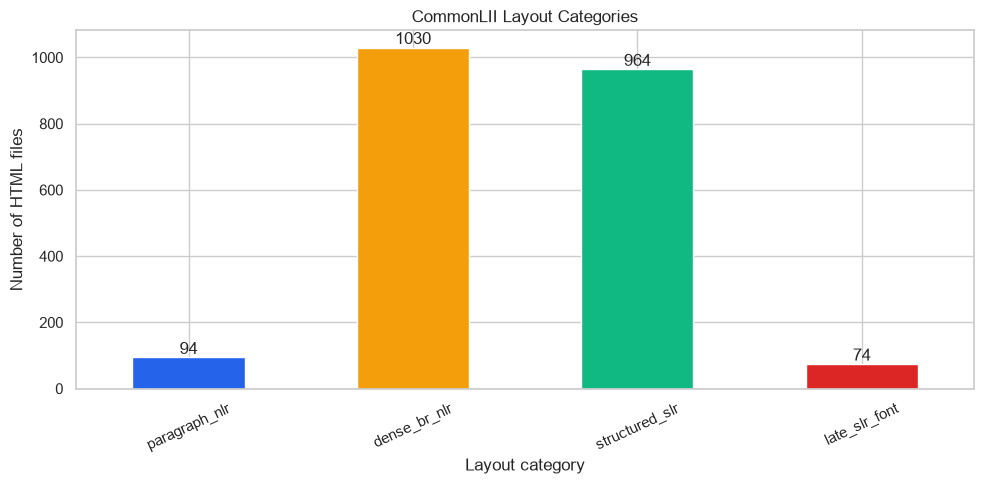

In [ ]:
category_counts = (
    df["category"]
    .value_counts()
    .reindex(LAYOUTS, fill_value=0)
)

ax = category_counts.plot(
    kind="bar",
    figsize=(10, 5),
    color=[COLORS[layout] for layout in category_counts.index],
)

ax.set_title("CommonLII Layout Categories")
ax.set_xlabel("Layout category")
ax.set_ylabel("Number of HTML files")
ax.tick_params(axis="x", rotation=25)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

## 5. Calculate four series-gated layout scores

The report series (NLR/SLR) routes 92% of the score mass to its own layout pair. A steep sigmoid over the one feature that separates that pair — `br_per_paragraph` for NLR, `font_per_paragraph` for SLR — splits the pair. Both features are normalized by paragraph count, so a long judgment with many raw tags does not read as a different layout; only genuine tag *density* does. Both are strongly bimodal in this archive (NLR files sit below 0.5 or above 1.5 br per paragraph; SLR files have under 0.06 or over 0.61 font tags per paragraph), so most files score above 0.9 and scores near 0.5 mark genuinely ambiguous pages. The fingerprint also records `br_per_1000_chars` and `font_per_1000_chars` as an alternative length normalization for cross-checking. These are still heuristic scores, not calibrated probabilities.

In [ ]:
def numeric(row, column, default=0.0):
    value = row.get(column, default)
    if pd.isna(value):
        return default
    return float(value)


# Both discriminating features are normalized by paragraph count so long
# judgments do not accumulate raw tag counts into a false layout signal.
# NLR br_per_paragraph is bimodal: paragraph-led pages sit below 0.5, br-led
# pages above 1.5, with a near-empty gap around 1.0. SLR font_per_paragraph is
# bimodal too: stray tags on long pages stay below 0.06, genuinely font-led
# pages sit above 0.61 (about one <font> per paragraph).
BR_MIDPOINT = 1.0
BR_STEEPNESS = 4.0
FONT_MIDPOINT = 0.3
FONT_STEEPNESS = 15.0
# Mass routed to the layout pair matching the detected report series. The
# residual keeps cross-series scores nonzero so a misdetected series still
# surfaces as a low-confidence file instead of a hard zero.
SERIES_PRIOR = 0.92


def sigmoid(value):
    return float(1.0 / (1.0 + np.exp(-value)))


def calculate_layout_scores(row):
    """Series-gated scoring: must stay in sync with
    scripts/1901-crawler/build_layout_categories.py::layout_scores."""
    report_series = str(row.get("report_series", "")).upper()

    br_ratio = numeric(row, "fingerprint.br_per_paragraph")
    font_ratio = numeric(row, "fingerprint.font_per_paragraph")

    br_evidence = sigmoid(BR_STEEPNESS * (br_ratio - BR_MIDPOINT))
    font_evidence = sigmoid(FONT_STEEPNESS * (font_ratio - FONT_MIDPOINT))

    if report_series == "NLR":
        nlr_mass, slr_mass = SERIES_PRIOR, 1.0 - SERIES_PRIOR
    elif report_series == "SLR":
        nlr_mass, slr_mass = 1.0 - SERIES_PRIOR, SERIES_PRIOR
    else:
        nlr_mass = slr_mass = 0.5

    return {
        "paragraph_nlr": nlr_mass * (1.0 - br_evidence),
        "dense_br_nlr": nlr_mass * br_evidence,
        "structured_slr": slr_mass * (1.0 - font_evidence),
        "late_slr_font": slr_mass * font_evidence,
    }


score_df = df.apply(calculate_layout_scores, axis=1, result_type="expand")
df[LAYOUTS] = score_df[LAYOUTS]

recomputed_category = df[LAYOUTS].idxmax(axis=1)
if not recomputed_category.equals(df["category"]):
    mismatch = int((recomputed_category != df["category"]).sum())
    raise ValueError(
        f"Notebook scoring disagrees with the generator for {mismatch} file(s); "
        "re-run build_layout_categories.py or sync the two implementations."
    )

display(df[["file", "year", "category"] + LAYOUTS].round(3))

,file,year,category,paragraph_nlr,dense_br_nlr,structured_slr,late_slr_font
0,1878/1.html,1878,paragraph_nlr,0.903,0.017,0.079,0.001
1,1878/2.html,1878,dense_br_nlr,0.002,0.918,0.079,0.001
2,1895/1.html,1895,paragraph_nlr,0.903,0.017,0.079,0.001
3,1895/2.html,1895,paragraph_nlr,0.898,0.022,0.079,0.001
4,1895/3.html,1895,dense_br_nlr,0.006,0.914,0.075,0.005
...,...,...,...,...,...,...,...
2157,2010/1.html,2010,late_slr_font,0.000,0.080,0.000,0.920
2158,2010/2.html,2010,late_slr_font,0.000,0.080,0.000,0.920
2159,2010/3.html,2010,late_slr_font,0.000,0.080,0.000,0.920
2160,2010/4.html,2010,late_slr_font,0.000,0.080,0.000,0.920


## 6. Four layout curves over time

Vertical dashed lines mark changes in the highest-scoring layout family. With sparse samples, treat these as candidate transitions for inspection.

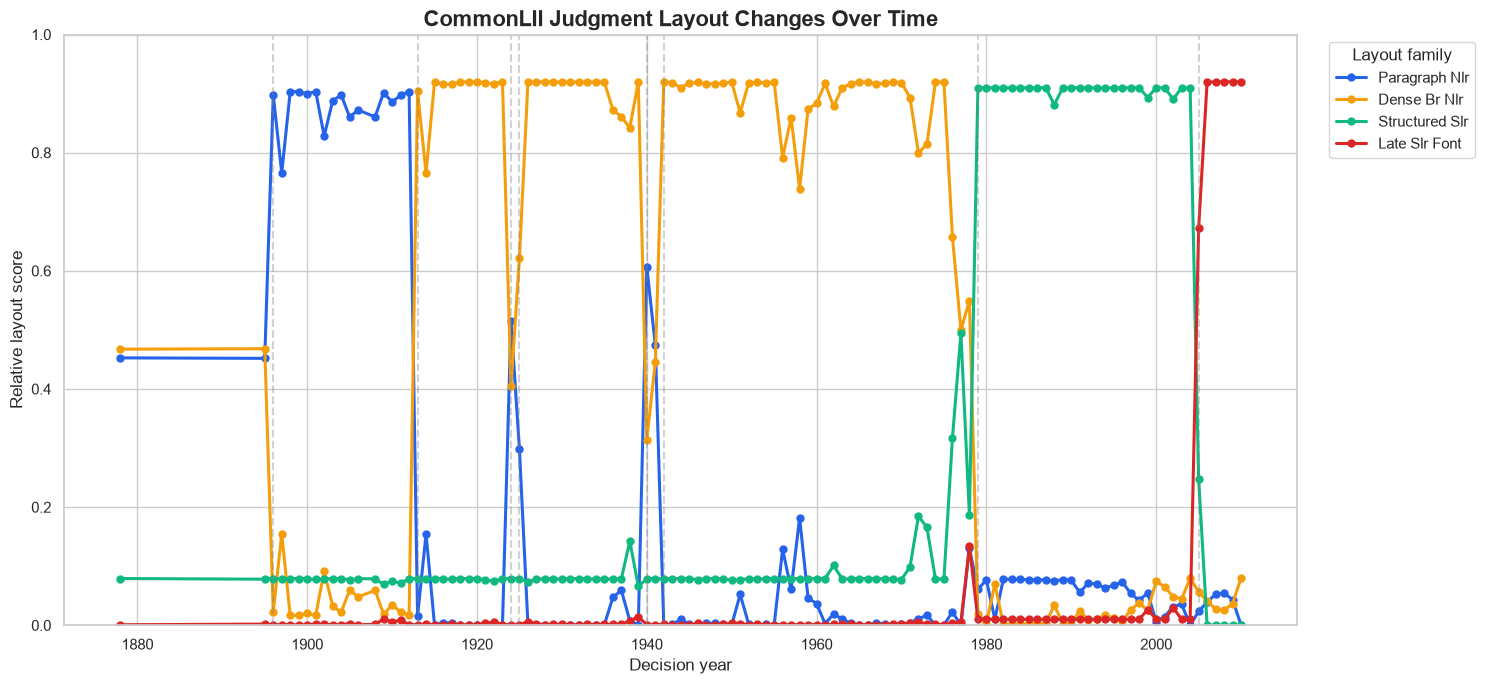

In [ ]:
yearly_scores = df.groupby("year")[LAYOUTS].mean().sort_index()
dominant_layout = yearly_scores.idxmax(axis=1)
change_years = dominant_layout[dominant_layout.ne(dominant_layout.shift())].index.tolist()

fig, ax = plt.subplots(figsize=(15, 7))

for layout in LAYOUTS:
    ax.plot(
        yearly_scores.index,
        yearly_scores[layout],
        marker="o",
        linewidth=2.2,
        markersize=5,
        label=layout.replace("_", " " ).title(),
        color=COLORS[layout],
    )

for year in change_years[1:]:
    ax.axvline(year, color="grey", linestyle="--", alpha=0.35)

ax.set_title("CommonLII Judgment Layout Changes Over Time", fontsize=16, fontweight="bold")
ax.set_xlabel("Decision year")
ax.set_ylabel("Relative layout score")
ax.set_ylim(0, 1)
ax.legend(title="Layout family", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

## 7. Layout heatmap

Scores are averaged by year before plotting, so the complete corpus remains readable when a year contains many judgments.

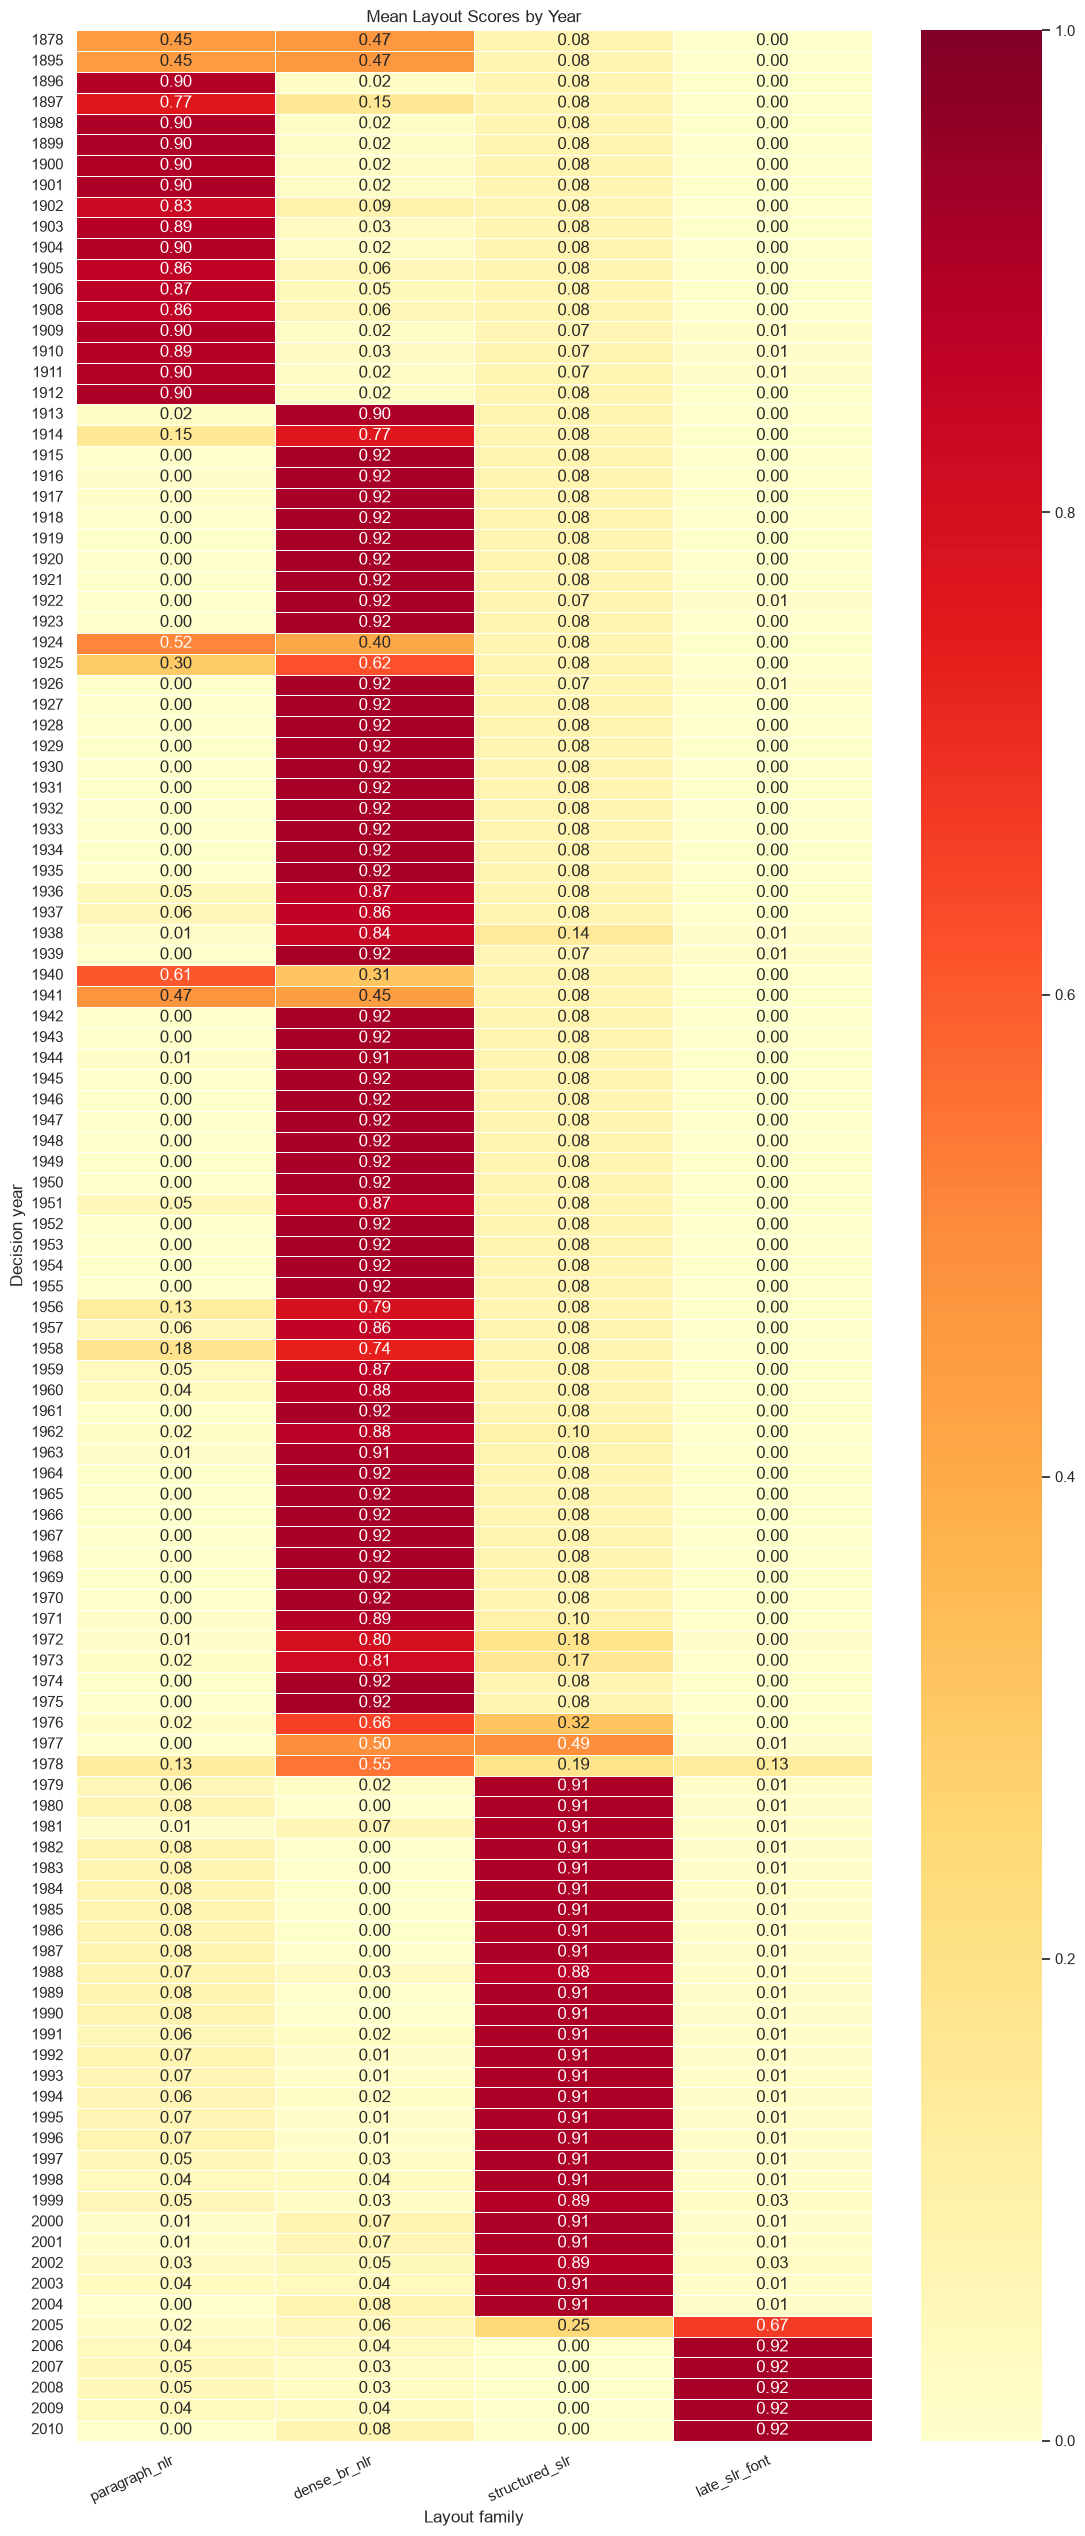

In [ ]:
plt.figure(figsize=(11, min(30, max(8, len(yearly_scores) * 0.22))))

sns.heatmap(
    yearly_scores,
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
)

plt.title("Mean Layout Scores by Year")
plt.xlabel("Layout family")
plt.ylabel("Decision year")
plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()

## 8. Candidate layout transitions

In [ ]:
timeline = yearly_scores.copy()
timeline["dominant_layout"] = timeline.idxmax(axis=1)
timeline["dominant_score"] = yearly_scores.max(axis=1)
timeline["layout_changed"] = timeline["dominant_layout"].ne(
    timeline["dominant_layout"].shift()
)

transitions = timeline.loc[
    timeline["layout_changed"],
    ["dominant_layout", "dominant_score"],
]

display(transitions)

,dominant_layout,dominant_score
year,,
1878,dense_br_nlr,0.467362
1896,paragraph_nlr,0.897521
1913,dense_br_nlr,0.904337
1924,paragraph_nlr,0.515576
1925,dense_br_nlr,0.622048
1940,paragraph_nlr,0.606476
1942,dense_br_nlr,0.919608
1979,structured_slr,0.909892
2005,late_slr_font,0.671747


## 9. Assigned layout distribution by decade

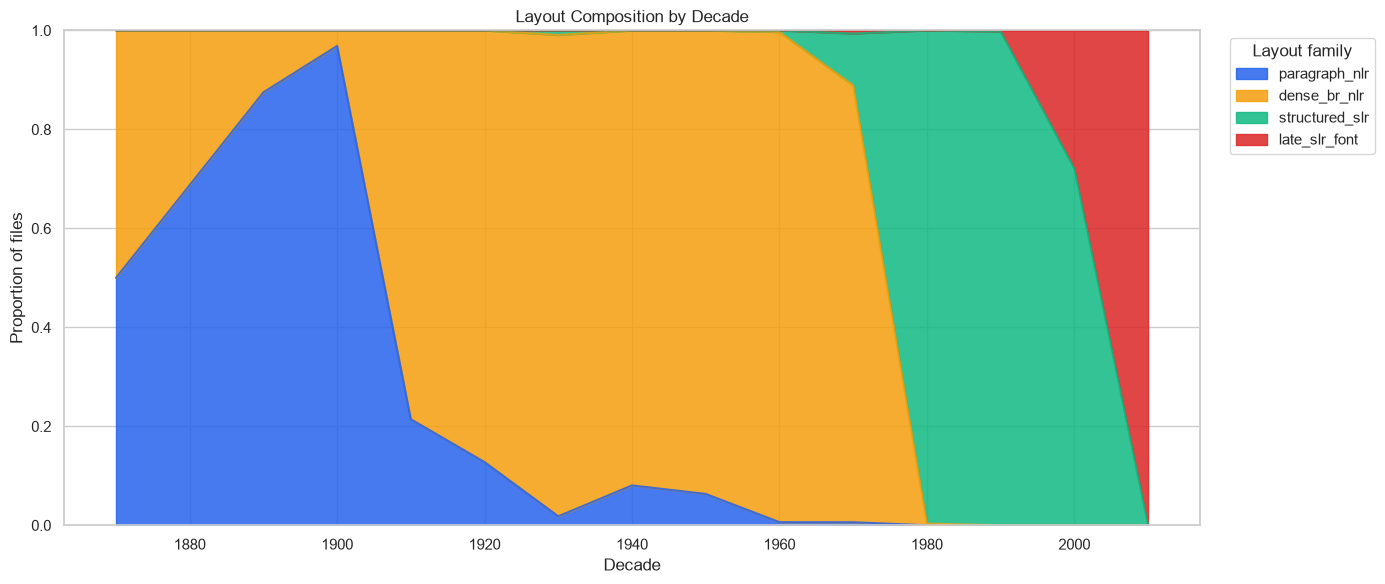

In [ ]:
df["decade"] = (df["year"] // 10) * 10

decade_distribution = pd.crosstab(
    df["decade"],
    df["category"],
    normalize="index",
).reindex(columns=LAYOUTS, fill_value=0)

ax = decade_distribution.plot(
    kind="area",
    stacked=True,
    figsize=(14, 6),
    color=[COLORS[layout] for layout in LAYOUTS],
    alpha=0.85,
)

ax.set_title("Layout Composition by Decade")
ax.set_xlabel("Decade")
ax.set_ylabel("Proportion of files")
ax.set_ylim(0, 1)
ax.legend(title="Layout family", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

## 10. Suspicious or uncertain classifications

With series-gated scoring, a confident file scores near 0.92 and its runner-up near 0. Files flagged here have a top score below 0.75 or a top-two margin below 0.5, which means their discriminating feature sits near the decision midpoint (br per paragraph near 1.0, or font tags per paragraph near 0.3) or the report series was not detected. These are the pages worth opening by hand.

In [ ]:
df["top_score"] = df[LAYOUTS].max(axis=1)
sorted_scores = np.sort(df[LAYOUTS].to_numpy(), axis=1)
df["score_margin"] = sorted_scores[:, -1] - sorted_scores[:, -2]

uncertain = df[(df["top_score"] < 0.75) | (df["score_margin"] < 0.5)]

print(f"Uncertain files: {len(uncertain)} of {len(df)}")
display(
    uncertain[
        ["file", "year", "category", "top_score", "score_margin"] + LAYOUTS
    ].sort_values("score_margin")
)

Uncertain files: 5 of 2162


,file,year,category,top_score,score_margin,paragraph_nlr,dense_br_nlr,structured_slr,late_slr_font
745,1962/24.html,1962,paragraph_nlr,0.564309,0.208618,0.564309,0.355691,0.079121,0.000879
770,1963/13.html,1963,dense_br_nlr,0.566281,0.212562,0.353719,0.566281,0.079121,0.000879
645,1958/9.html,1958,paragraph_nlr,0.651968,0.383936,0.651968,0.268032,0.079121,0.000879
12,1897/1.html,1897,paragraph_nlr,0.654683,0.389365,0.654683,0.265317,0.078584,0.001416
618,1958/13.html,1958,paragraph_nlr,0.745841,0.571682,0.745841,0.174159,0.079121,0.000879


## 11. Save EDA tables and the timeline chart

Saved EDA outputs to: D:\projects\Draftly-Project\draftly-research\data\commonlii\layout-eda


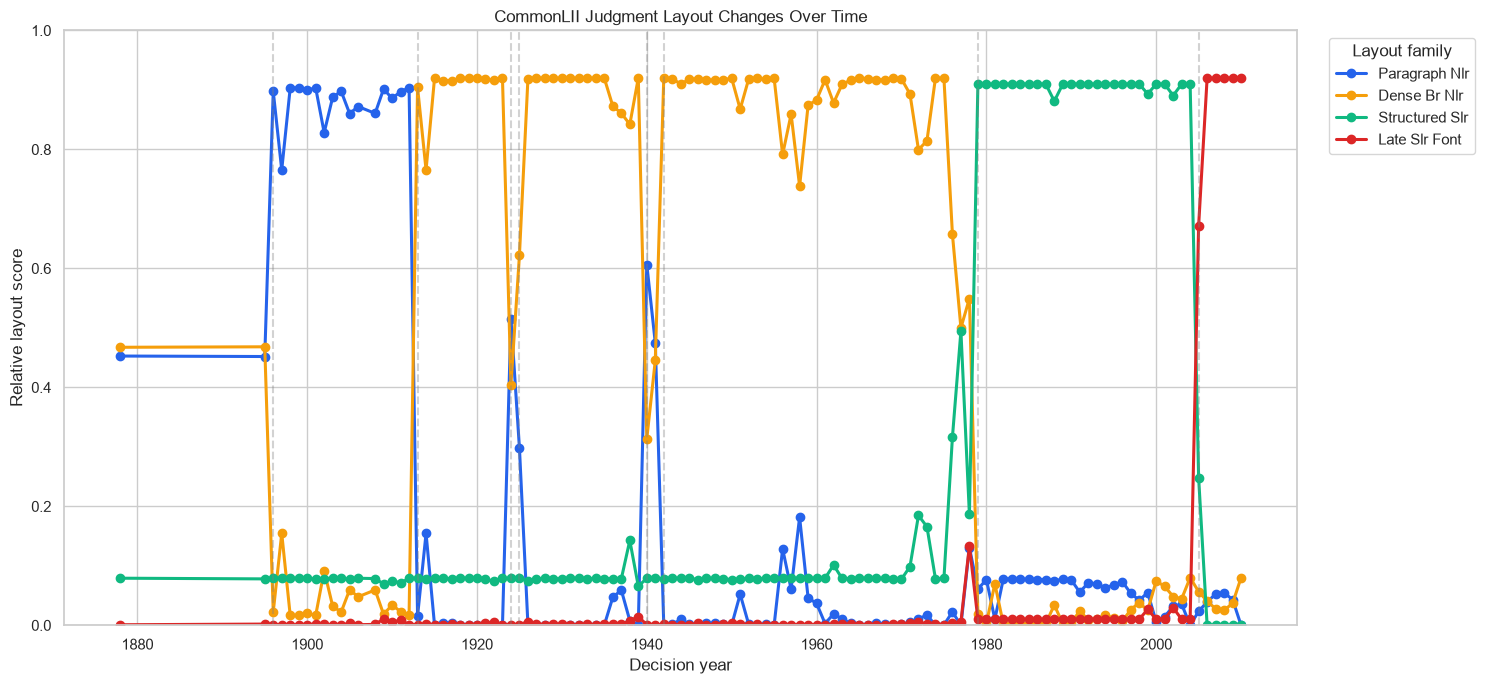

In [ ]:
OUTPUT_DIR = JSON_PATH.parent / "layout-eda"
OUTPUT_DIR.mkdir(exist_ok=True)

df.to_csv(OUTPUT_DIR / "layout-eda-records.csv", index=False)
yearly_scores.to_csv(OUTPUT_DIR / "layout-scores-by-year.csv")
transitions.to_csv(OUTPUT_DIR / "layout-transitions.csv")
uncertain.to_csv(OUTPUT_DIR / "uncertain-layouts.csv", index=False)

fig, ax = plt.subplots(figsize=(15, 7))

for layout in LAYOUTS:
    ax.plot(
        yearly_scores.index,
        yearly_scores[layout],
        marker="o",
        linewidth=2.2,
        label=layout.replace("_", " " ).title(),
        color=COLORS[layout],
    )

for year in change_years[1:]:
    ax.axvline(year, color="grey", linestyle="--", alpha=0.35)

ax.set_title("CommonLII Judgment Layout Changes Over Time")
ax.set_xlabel("Decision year")
ax.set_ylabel("Relative layout score")
ax.set_ylim(0, 1)
ax.legend(title="Layout family", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "layout-changes-over-time.png", dpi=300, bbox_inches="tight")

print(f"Saved EDA outputs to: {OUTPUT_DIR.resolve()}")
plt.show()

---

# Part 2 — Extraction EDA

Part 1 classified the HTML layouts. Part 2 explores what the parsers pulled out of
those files: `src/parsers/parse_archive.py` writes one evidence-linked record per
judgment to `data/commonlii/parsed/records/*.jsonl`, holding roughly forty fields
plus the block list each value was read from.

Two things to keep in mind while reading these charts:

- **Coverage is not accuracy.** A populated field can still be wrong. Section 16
  separates the two for the three fields where the gap is widest.
- **A null is often correct.** The NLR reporter did not print hearing dates, and an
  original-jurisdiction application has no lower court. Section 14 shows how much of
  the apparent shortfall is print convention rather than parser failure.

## 12. Load the extraction records

In [ ]:
RECORDS_DIR = JSON_PATH.parent / "parsed" / "records"
BUCKETS = [
    "dense_br_nlr",
    "structured_slr",
    "paragraph_nlr",
    "late_slr_font",
    "uncertain",
]

if not RECORDS_DIR.exists():
    raise FileNotFoundError(
        f"{RECORDS_DIR} not found. The parsed records are derived data and are "
        "gitignored; rebuild them with:\n"
        "  python src/parsers/split_categories.py\n"
        "  python src/parsers/parse_archive.py"
    )

records = []
for bucket in BUCKETS:
    with (RECORDS_DIR / f"{bucket}.jsonl").open(encoding="utf-8") as handle:
        records.extend(json.loads(line) for line in handle)

if len(records) != len(df):
    raise ValueError(
        f"{len(records)} extraction records but {len(df)} fingerprinted files; "
        "re-run parse_archive.py so both views describe the same corpus."
    )


# Each entry counts items for a list field, or 0/1 for a scalar. Ordered
# roughly by expected coverage so the bar chart in section 13 reads top-down.
EXTRACTED_FIELDS = {
    "neutral citation": lambda r: r["identity"]["neutral_citation"],
    "decision date": lambda r: r["dates"]["decision_date"],
    "parties": lambda r: r["parties"],
    "party roles": lambda r: [p for p in r["parties"] if p["role"]],
    "printed pages": lambda r: r["report"]["printed_pages"],
    "disposition": lambda r: r["judgment"]["disposition"],
    "proceeding type": lambda r: r["case_details"]["proceeding_type"],
    "bench": lambda r: r["bench"],
    "opinion author": lambda r: r["judgment"]["opinion_author"],
    "legislation": lambda r: r["authorities"]["legislation"],
    "catchwords": lambda r: r["headnote"]["catchwords"],
    "facts summary": lambda r: r["headnote"]["facts_summary"],
    "case numbers": lambda r: r["case_details"]["case_numbers"],
    "counsel": lambda r: r["representation"]["counsel"],
    "costs order": lambda r: r["judgment"]["costs_order"],
    "holdings": lambda r: r["headnote"]["holdings"],
    "cases cited": lambda r: r["authorities"]["cases_cited"],
    "hearing dates": lambda r: r["dates"]["hearing_dates"],
    "cases referred to": lambda r: r["headnote"]["cases_referred_to"],
    "lower court numbers": lambda r: r["case_details"]["lower_court_case_numbers"],
    "originating court": lambda r: r["case_details"]["originating_court"],
}

ERA_BINS = [1870, 1920, 1950, 1979, 2000, 2011]
ERA_LABELS = ["1878-1919", "1920-1949", "1950-1978", "1979-1999", "2000-2010"]


def item_count(value):
    """Items in a list field; 1 or 0 for a scalar."""
    if value is None or value == "":
        return 0
    if isinstance(value, (list, tuple, dict)):
        return len(value)
    return 1


rows = []
for record in records:
    row = {
        "case_id": record["identity"]["case_id"],
        "file": record["provenance"]["file"],
        "bucket": record["layout"]["bucket"],
        "series": record["report"]["series"],
        "court": record["identity"]["deciding_court"],
        "year": int(record["dates"]["decision_date"][:4]),
        "blocks": len(record["blocks"]),
        "chars": sum(len(block["text"]) for block in record["blocks"]),
    }
    row.update(
        (label, item_count(accessor(record)))
        for label, accessor in EXTRACTED_FIELDS.items()
    )
    row.update(
        (f"flag: {flag}", bool(value))
        for flag, value in record["quality"].items()
        if isinstance(value, bool)
    )
    rows.append(row)

extraction = pd.DataFrame(rows)
extraction["era"] = pd.cut(
    extraction["year"], bins=ERA_BINS, labels=ERA_LABELS, right=False
)

FIELD_NAMES = list(EXTRACTED_FIELDS)
FLAG_NAMES = [column for column in extraction.columns if column.startswith("flag: ")]

print(f"Extraction records: {len(extraction):,}")
print(f"Fields tracked: {len(FIELD_NAMES)}  |  quality flags: {len(FLAG_NAMES)}")
print(
    f"Corpus text: {extraction['chars'].sum():,} characters "
    f"in {extraction['blocks'].sum():,} evidence blocks"
)
display(extraction.head())

NameError: name 'JSON_PATH' is not defined

## 13. Field coverage

Share of the 2,162 judgments where each field was populated, with the total number of
extracted items beside it. One bar per field, so identity comes from the axis label
rather than colour.

In [ ]:
# Categorical slots from the validated reference palette (blue / orange / aqua).
SERIES_1, SERIES_2, SERIES_3 = "#2a78d6", "#eb6834", "#1baf7a"
SURFACE = "#fcfcfb"
INK, INK_MUTED = "#0b0b0b", "#52514e"

coverage = (
    pd.DataFrame(
        {
            "records": (extraction[FIELD_NAMES] > 0).sum(),
            "items": extraction[FIELD_NAMES].sum(),
        }
    )
    .assign(share=lambda frame: frame["records"] / len(extraction))
    .sort_values("share")
)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(coverage.index, coverage["share"], color=SERIES_1, height=0.68)

for name, row in coverage.iterrows():
    ax.text(
        row["share"] + 0.012,
        name,
        f"{row['share']:.0%}   {row['records']:,} recs · {row['items']:,} items",
        va="center",
        fontsize=9,
        color=INK_MUTED,
    )

ax.set_xlim(0, 1.42)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.set_xlabel("Share of judgments with the field populated")
ax.set_title("Extraction coverage by field", fontsize=14, fontweight="bold", color=INK)
ax.grid(axis="y", visible=False)
sns.despine(ax=ax, left=True, bottom=True)

plt.tight_layout()
plt.show()

display(
    coverage.sort_values("share", ascending=False)
    .assign(**{"coverage %": lambda frame: (frame["share"] * 100).round(1)})
    .drop(columns="share")
)

## 14. Coverage over time — print convention, not parser failure

The four fields with the largest gaps are also the four that depend most on what the
reporter chose to print. Holdings and hearing dates step up sharply at the NLR→SLR
boundary in 1979, because the SLR reporter introduced numbered `Held:` blocks and a
printed hearing line; the NLR reporter printed neither. Counsel, which both reporters
always printed, stays flat and high across 130 years.

Read this chart before treating any coverage number as a parser score.

In [ ]:
TREND_FIELDS = {
    "counsel": SERIES_1,
    "cases cited": SERIES_2,
    "holdings": SERIES_3,
    "hearing dates": "#eda100",  # slot 4
}
SLR_BOUNDARY = 1979

decade = extraction.assign(decade=(extraction["year"] // 10) * 10)
trend = (
    decade.groupby("decade")[list(TREND_FIELDS)]
    .apply(lambda group: (group > 0).mean())
    .sort_index()
)
decade_counts = decade.groupby("decade").size()
# Decades with a handful of judgments make a noisy rate; drop them.
trend = trend[decade_counts >= 20]

fig, ax = plt.subplots(figsize=(13, 6))
ax.axvline(SLR_BOUNDARY, color="#b8b7b0", linestyle="--", linewidth=1.4, zorder=1)
ax.text(
    SLR_BOUNDARY + 1.5,
    0.04,
    "NLR → SLR (1979)",
    fontsize=9,
    color=INK_MUTED,
)

for field, colour in TREND_FIELDS.items():
    ax.plot(
        trend.index,
        trend[field],
        color=colour,
        linewidth=2,
        marker="o",
        markersize=8,
        markeredgecolor=SURFACE,
        markeredgewidth=2,
        label=field,
        zorder=2,
    )
    # Direct label at the series end so identity is never colour-alone.
    ax.text(
        trend.index[-1] + 2,
        trend[field].iloc[-1],
        field,
        color=colour,
        fontsize=10,
        fontweight="bold",
        va="center",
    )

ax.set_xlim(trend.index[0] - 4, trend.index[-1] + 28)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.set_xlabel("Decade")
ax.set_ylabel("Share of judgments with the field populated")
ax.set_title(
    "Field coverage by decade", fontsize=14, fontweight="bold", color=INK
)
ax.legend(title="Field", loc="lower left", frameon=False)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

era_coverage = (
    extraction.groupby("era", observed=True)[FIELD_NAMES]
    .apply(lambda group: (group > 0).mean())
    .mul(100)
    .round(0)
    .astype(int)
)
era_coverage.insert(0, "judgments", extraction.groupby("era", observed=True).size())
display(era_coverage[["judgments", "bench", "counsel", "holdings",
                      "cases cited", "hearing dates", "originating court"]])

## 15. Coverage by layout bucket

The same picture cut by layout family instead of date. `late_slr_font` and
`structured_slr` are the modern, well-structured pages; `paragraph_nlr` holds the
earliest and least regular captions and is the weakest bucket on every field.
Sequential single-hue scale — darker means higher coverage.

In [ ]:
bucket_coverage = (
    extraction.groupby("bucket")[FIELD_NAMES]
    .apply(lambda group: (group > 0).mean())
    .reindex(BUCKETS)
    .mul(100)
)
bucket_sizes = extraction["bucket"].value_counts().reindex(BUCKETS)
bucket_coverage.index = [
    f"{bucket}\n(n={bucket_sizes[bucket]:,})" for bucket in bucket_coverage.index
]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    bucket_coverage,
    cmap="Blues",
    vmin=0,
    vmax=100,
    annot=True,
    fmt=".0f",
    linewidths=2,
    linecolor=SURFACE,
    cbar_kws={"label": "coverage %"},
    annot_kws={"fontsize": 8},
    ax=ax,
)
ax.set_title(
    "Field coverage by layout bucket (%)", fontsize=14, fontweight="bold", color=INK
)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=40, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

## 16. Coverage is not usability

Three fields carry known defects, so the extracted-item count overstates what is
usable downstream. This cell measures the gap directly rather than restating the
coverage number.

- **Holdings** — `extract_headnote` sets `in_held` at the `Held` block and never
  clears it, so the facts summary, counsel lines and `Cur. adv. vult.` are appended
  to the last holding. Items carrying a run-on marker, or longer than 1,200
  characters, are counted defective.
- **Cases cited** — `CASE_NAME_RE` starts at the earliest capital, so an
  introducing clause is absorbed into the party name
  (`'This question was considered by Shaw J. in Usoof v. Zainudeen'`). The citation
  string itself is unaffected.
- **Catchwords** — the splitter breaks on every hyphen, including word-internal
  ones, so `Co-owners` becomes `'Co'` + `'owners'`. Orphaned lowercase-leading
  fragments are counted defective; the preceding entry is truncated too, so the real
  damage is roughly double the count shown.

The bars are stacked usable-first with a surface gap between segments.

In [ ]:
import re

HOLDING_RUNON = re.compile(
    r"Cur\.?\s*adv\.?\s*vult"
    r"|\bfor the (?:appellant|respondent|petitioner|plaintiff|defendant)"
    r"|\b(?:THIS|THE|APPEAL|APPLICATION) [A-Z]{2}"
)
NAME_PROSE = re.compile(
    r"\b(?:in|of|by|case|judgment|decision|said|per|see|cf|vide|that|was|the)\s+[A-Z]"
)

usability = {}

holdings = [h for r in records for h in r["headnote"]["holdings"]]
bad_holdings = [
    h for h in holdings
    if HOLDING_RUNON.search(h["text"]) or len(h["text"]) > 1200
]
usability["holdings\n(candidate rules)"] = (
    len(holdings) - len(bad_holdings), len(bad_holdings), "run-on / oversized"
)

cited = [c for r in records for c in r["authorities"]["cases_cited"]]
bad_names = [c for c in cited if c["case_name"] and NAME_PROSE.search(c["case_name"])]
usability["cases cited\n(graph edges)"] = (
    len(cited) - len(bad_names), len(bad_names), "name has prose prefix"
)

catchwords = [c for r in records for c in r["headnote"]["catchwords"]]
bad_catchwords = [c for c in catchwords if c and c[0].islower()]
usability["catchwords\n(topics)"] = (
    len(catchwords) - len(bad_catchwords), len(bad_catchwords), "hyphen-split fragment"
)

labels = list(usability)
clean = np.array([usability[label][0] for label in labels], dtype=float)
defective = np.array([usability[label][1] for label in labels], dtype=float)

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.barh(labels, clean, color=SERIES_1, height=0.55,
        edgecolor=SURFACE, linewidth=2, label="usable")
ax.barh(labels, defective, left=clean, color=SERIES_2, height=0.55,
        edgecolor=SURFACE, linewidth=2, label="known defect")

for index, label in enumerate(labels):
    total = clean[index] + defective[index]
    ax.text(clean[index] / 2, index, f"{clean[index]:,.0f}\n{clean[index]/total:.0%}",
            ha="center", va="center", color="white", fontsize=10, fontweight="bold")
    ax.text(total + total * 0.015, index,
            f"{defective[index]:,.0f} {usability[label][2]}",
            va="center", fontsize=9, color=INK_MUTED)

ax.set_xlim(0, max(clean + defective) * 1.42)
ax.set_xlabel("Extracted items")
ax.set_title("Usable vs defective extracted items",
             fontsize=14, fontweight="bold", color=INK)
ax.legend(loc="lower right", frameon=False)
ax.grid(axis="y", visible=False)
sns.despine(ax=ax, left=True, bottom=True)

plt.tight_layout()
plt.show()

usability_table = pd.DataFrame(
    [
        {
            "field": label.replace("\n", " "),
            "items": int(clean[index] + defective[index]),
            "usable": int(clean[index]),
            "defective": int(defective[index]),
            "usable %": round(clean[index] / (clean[index] + defective[index]) * 100, 1),
            "defect": usability[label][2],
        }
        for index, label in enumerate(labels)
    ]
)
display(usability_table)

## 17. Citation graph

Every citation is resolved against the corpus's own `report` fields — series, volume
and start page — so an edge counts as *internal* only when both endpoints are
judgments present in this archive. External edges are still useful as graph nodes;
they simply point at judgments CommonLII does not hold, or at English and Indian
reports.

In [ ]:
CITATION_PARTS = re.compile(
    r"(?:\((?P<year>\d{4})\)\s*)?(?P<volume>\d{1,3})\s*"
    r"(?P<series>N\.?\s?L\.?\s?R|Sri\s?L\.?\s?R|S\.?\s?L\.?\s?R)\.?\s*,?\s*"
    r"(?P<page>\d+)",
    re.I,
)

# (series, volume, start page) -> case_id, for resolving citations back to records.
corpus_index = {
    (
        record["report"]["series"],
        record["report"]["volume"],
        record["report"]["start_page"],
    ): record["identity"]["case_id"]
    for record in records
    if record["report"]["volume"] and record["report"]["start_page"]
}

edges = []
for record in records:
    for citation in record["authorities"]["cases_cited"]:
        match = CITATION_PARTS.search(citation["citation"])
        target = None
        if match:
            raw_series = match["series"].upper().replace(" ", "").replace(".", "")
            series = "SLR" if raw_series.startswith("SRI") or raw_series == "SLR" else "NLR"
            target = corpus_index.get(
                (series, int(match["volume"]), int(match["page"]))
            )
        edges.append(
            {
                "source": record["identity"]["case_id"],
                "target": target,
                "citation": citation["citation"],
                "case_name": citation["case_name"],
                "treatment": citation["treatment"],
                "local_series": bool(match),
            }
        )

edge_frame = pd.DataFrame(edges)
internal = edge_frame[edge_frame["target"].notna()]

print(f"citation mentions       : {len(edge_frame):,}")
print(f"  cite NLR/SLR          : {int(edge_frame['local_series'].sum()):,}")
print(f"  resolve inside corpus : {len(internal):,}  "
      f"({len(internal) / max(int(edge_frame['local_series'].sum()), 1):.0%} of NLR/SLR cites)")
print(f"distinct citing judgments : {edge_frame['source'].nunique():,}")
print(f"distinct cited judgments  : {internal['target'].nunique():,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

composition = pd.Series(
    {
        "internal\n(both ends in corpus)": len(internal),
        "NLR/SLR, not held": int(edge_frame["local_series"].sum()) - len(internal),
        "foreign / other reports": int((~edge_frame["local_series"]).sum()),
    }
)
axes[0].bar(
    range(len(composition)), composition.to_numpy(),
    color=[SERIES_1, SERIES_3, "#c9c8c0"], width=0.62,
)
axes[0].set_xticks(range(len(composition)))
axes[0].set_xticklabels(composition.index, fontsize=9)
for index, value in enumerate(composition):
    axes[0].text(index, value + max(composition) * 0.02, f"{value:,}",
                 ha="center", fontsize=10, fontweight="bold", color=INK)
axes[0].set_ylim(0, max(composition) * 1.18)
axes[0].set_ylabel("Citation edges")
axes[0].set_title("Edge composition", fontsize=12, fontweight="bold", color=INK)
axes[0].grid(axis="x", visible=False)
sns.despine(ax=axes[0], left=True)

most_cited = internal["target"].value_counts().head(10).sort_values()
axes[1].barh(most_cited.index, most_cited.to_numpy(), color=SERIES_1, height=0.66)
for case_id, value in most_cited.items():
    axes[1].text(value + 0.15, case_id, str(value), va="center",
                 fontsize=9, color=INK_MUTED)
axes[1].set_xlim(0, most_cited.max() * 1.18)
axes[1].set_xlabel("Times cited within the corpus")
axes[1].set_title("Most-cited judgments", fontsize=12, fontweight="bold", color=INK)
axes[1].grid(axis="y", visible=False)
sns.despine(ax=axes[1], left=True, bottom=True)

plt.tight_layout()
plt.show()

print("\nCitation treatments:")
display(
    edge_frame["treatment"]
    .value_counts()
    .rename_axis("treatment")
    .reset_index(name="edges")
)

## 18. Statutes and dispositions

Two views of what the corpus is about: which statutes it argues over, and how the
court disposed of the matters. Statute titles are counted once per judgment, since a
single act is usually cited several times in one opinion.

Caveat on the statute counts: titles are not entity-resolved, so OCR and spelling
variants of one act still count separately, and section-level attribution has a known
window bug (a provision can be attached to the statute named before the one it
belongs to).

In [ ]:
statute_links = pd.DataFrame(
    [
        {"case_id": record["identity"]["case_id"], "statute": statute["title"],
         "provisions": len(statute["provisions"])}
        for record in records
        for statute in record["authorities"]["legislation"]
    ]
).drop_duplicates(subset=["case_id", "statute"])

dispositions = (
    pd.Series(
        [
            re.sub(r"\s+", " ", record["judgment"]["disposition"]).strip(" .").lower()
            for record in records
            if record["judgment"]["disposition"]
        ]
    )
    .value_counts()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_statutes = statute_links["statute"].value_counts().head(12).sort_values()
axes[0].barh(top_statutes.index, top_statutes.to_numpy(), color=SERIES_1, height=0.68)
for statute, value in top_statutes.items():
    axes[0].text(value + 3, statute, str(value), va="center", fontsize=9, color=INK_MUTED)
axes[0].set_xlim(0, top_statutes.max() * 1.16)
axes[0].set_xlabel("Judgments citing the statute")
axes[0].set_title("Most-cited statutes", fontsize=12, fontweight="bold", color=INK)
axes[0].grid(axis="y", visible=False)
sns.despine(ax=axes[0], left=True, bottom=True)

top_dispositions = dispositions.head(12).sort_values()
axes[1].barh(top_dispositions.index, top_dispositions.to_numpy(),
             color=SERIES_3, height=0.68)
for label, value in top_dispositions.items():
    axes[1].text(value + 3, label, str(value), va="center", fontsize=9, color=INK_MUTED)
axes[1].set_xlim(0, top_dispositions.max() * 1.16)
axes[1].set_xlabel("Judgments")
axes[1].set_title("Most common dispositions", fontsize=12, fontweight="bold", color=INK)
axes[1].grid(axis="y", visible=False)
sns.despine(ax=axes[1], left=True, bottom=True)

plt.tight_layout()
plt.show()

print(f"case→statute links (deduped) : {len(statute_links):,}")
print(f"distinct statute titles      : {statute_links['statute'].nunique():,}")
print(f"links carrying a provision   : {int((statute_links['provisions'] > 0).sum()):,}")
print(f"distinct disposition wordings: {len(dispositions):,}")

## 19. Quality flags and the manual-review worklist

`quality` flags travel with every record. `has_encoding_errors` and
`has_malformed_tags` describe the *source* HTML (stray `</font>` closers, replacement
characters) rather than an extraction failure — they mark files worth trusting less.
`author_not_on_bench` is a genuine cross-check: the opinion author's surname is
matched, allowing for OCR drift, against the extracted bench, so a record trips it
only when one of the two fields is wrong.

In [ ]:
flag_counts = extraction[FLAG_NAMES].sum().sort_values()
flag_counts.index = [name.removeprefix("flag: ") for name in flag_counts.index]

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.barh(flag_counts.index, flag_counts.to_numpy(), color=SERIES_2, height=0.6)
for name, value in flag_counts.items():
    ax.text(value + len(extraction) * 0.008, name,
            f"{value:,}  ({value / len(extraction):.1%})",
            va="center", fontsize=9, color=INK_MUTED)
ax.set_xlim(0, max(flag_counts.max() * 1.5, 10))
ax.set_xlabel("Judgments flagged")
ax.set_title("Quality flags", fontsize=13, fontweight="bold", color=INK)
ax.grid(axis="y", visible=False)
sns.despine(ax=ax, left=True, bottom=True)

plt.tight_layout()
plt.show()

review = extraction[extraction["flag: author_not_on_bench"]]
print(f"Records for manual review (author not on bench): {len(review)}")
display(review[["case_id", "file", "bucket", "year"]].head(15))

print("\nSource-quality flags by era (% of judgments):")
display(
    extraction.groupby("era", observed=True)[
        ["flag: has_encoding_errors", "flag: has_malformed_tags"]
    ]
    .mean()
    .mul(100)
    .round(0)
    .astype(int)
    .rename(columns=lambda name: name.removeprefix("flag: "))
)

## 20. Save the extraction EDA tables

In [ ]:
EXTRACTION_DIR = JSON_PATH.parent / "extraction-eda"
EXTRACTION_DIR.mkdir(exist_ok=True)

extraction.to_csv(EXTRACTION_DIR / "extraction-records.csv", index=False)
coverage.sort_values("share", ascending=False).to_csv(
    EXTRACTION_DIR / "field-coverage.csv"
)
era_coverage.to_csv(EXTRACTION_DIR / "coverage-by-era.csv")
bucket_coverage.round(1).to_csv(EXTRACTION_DIR / "coverage-by-bucket.csv")
usability_table.to_csv(EXTRACTION_DIR / "usability.csv", index=False)
edge_frame.to_csv(EXTRACTION_DIR / "citation-edges.csv", index=False)
internal.to_csv(EXTRACTION_DIR / "citation-edges-internal.csv", index=False)
statute_links.to_csv(EXTRACTION_DIR / "case-statute-links.csv", index=False)
review[["case_id", "file", "bucket", "year"]].to_csv(
    EXTRACTION_DIR / "manual-review-worklist.csv", index=False
)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(coverage.index, coverage["share"], color=SERIES_1, height=0.68)
for name, row in coverage.iterrows():
    ax.text(row["share"] + 0.012, name, f"{row['share']:.0%}",
            va="center", fontsize=9, color=INK_MUTED)
ax.set_xlim(0, 1.12)
ax.xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.set_xlabel("Share of judgments with the field populated")
ax.set_title("Extraction coverage by field", fontsize=14, fontweight="bold", color=INK)
ax.grid(axis="y", visible=False)
sns.despine(ax=ax, left=True, bottom=True)
fig.tight_layout()
fig.savefig(EXTRACTION_DIR / "field-coverage.png", dpi=300, bbox_inches="tight")
plt.close(fig)

print(f"Saved extraction EDA outputs to: {EXTRACTION_DIR.resolve()}")
for path in sorted(EXTRACTION_DIR.iterdir()):
    print(f"  {path.name:34s} {path.stat().st_size / 1024:8.1f} KB")

---

## Interpretation guide

### Part 1 — layouts

- A rising blue curve indicates stronger paragraph-led NLR structure.
- Orange indicates increasing reliance on `<br>` elements.
- Green indicates structured SLR pages with recognizable semantic markers.
- Red indicates formatting-heavy later SLR pages.
- Dashed vertical lines indicate a change in the highest-scoring family.

The notebook scans the full HTML archive, but these classifications remain heuristic.
Manually review low-margin cases before treating a transition year as a stable parser
boundary.

### Part 2 — extraction

- **Coverage is a floor, not a score.** Section 14 shows holdings and hearing dates
  stepping up at the 1979 NLR→SLR boundary because the SLR reporter began printing
  numbered holdings and a hearing line. Counsel, printed by both reporters, stays
  flat and high. Judge a field against what the reporter actually printed, not
  against 2,162.
- **Two fields have a real ceiling well below the corpus size.** Hearing dates are
  absent from the NLR series by convention, and an original-jurisdiction matter — a
  writ application, an Art. 126 fundamental-rights application, an election petition
  — has no originating court. For both, a null is usually the correct answer.
- **Check section 16 before building on a field.** Holdings, cases-cited names and
  catchwords each carry a known defect, so the item count overstates what is usable.
  Holdings run past the actual holding; citation names can absorb an introducing
  clause; catchwords split on word-internal hyphens.
- **The citation graph is real but partial.** Only edges resolving inside this
  archive can be traversed; the rest point at judgments CommonLII does not hold, or
  at foreign reports.
- **Every value is traceable.** Each record carries a `blocks` list with
  `block_index`, `report_page` and the split reason, and most extracted items store
  the `block_index` they came from — so any number in these charts can be checked
  against the paragraph it was read from.